Transaction Fraud analysis Indicator
Life cycle of Machine learning Project

Understanding the Problem Statement
Data Collection
Data Checks to perform
Exploratory data analysis
Data Pre-Processing
Model Training
Choose best model

1) Problem statement

This project understands how the fraud transaction is affected by other variables 

2) Data Collection

Dataset Source - Transaction.csv
The data consists of ___ column and __ rows.

2.1 Import Data and Required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [23]:
%pip install numpy pandas seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


Import the CSV Data as Pandas DataFrame

In [9]:
df= pd.read_csv('transaction.csv')

Show Top 5 Records

In [10]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


Shape of the dataset

In [11]:
df.shape

(10000, 10)

2.2 Dataset information

transaction_id - ID of the transaction
user_id - ID of the customer
amount - Amount of transaction
transaction_type - Type of the transaction
merchant_category - Category of the merchant
country - Transaction Country
hour - Hour of the transaction
device_risk_score - Risk score associated with device
ip_risk_score - Riak score associated with IP
is_fraud - Type of transaction is Fraud or not

3. Data Checks to perform

Check Missing values
Check Duplicates
Check data type
Check the number of unique values of each column
Check statistics of data set
Check various categories present in the different categorical column

In [14]:
df.isna().sum()

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

There are no missing values in the data set

3.2 Check Duplicates

In [15]:
df.duplicated().sum()

0

There are no duplicates values in the data set

3.3 Check data types

In [16]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  object 
 4   merchant_category  10000 non-null  object 
 5   country            10000 non-null  object 
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


3.4 Checking the number of unique values of each column

In [17]:
df.nunique()

transaction_id       10000
user_id               1000
amount                9639
transaction_type         4
merchant_category        5
country                  6
hour                    24
device_risk_score    10000
ip_risk_score        10000
is_fraud                 2
dtype: int64

3.5 Check statistics of data set

In [18]:
df.describe()

,transaction_id,user_id,amount,hour,device_risk_score,ip_risk_score,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4999.50000,500.058700,178.142763,14.247100,0.183773,0.184669,0.050000
std,2886.89568,288.328495,531.647950,5.347383,0.177381,0.175772,0.217956
min,0.00000,0.000000,1.000000,0.000000,0.000030,0.000009,0.000000
25%,2499.75000,247.000000,65.084753,10.000000,0.075721,0.077762,0.000000
50%,4999.50000,503.000000,101.686510,14.000000,0.156583,0.158290,0.000000
75%,7499.25000,750.250000,138.280872,19.000000,0.234939,0.236968,0.000000
max,9999.00000,999.000000,11628.213881,23.000000,0.998737,0.999603,1.000000


Amount skew is the most critical finding — with a mean nearly double the median and a max of $11,628, the distribution is heavily right-tailed. Any ML model should receive log-transformed amounts.

Device & IP risk scores move almost in lockstep across all percentiles (25th → 100th), suggesting they're capturing the same underlying signal. A correlation check is strongly advised before including both in a model.

Hour shows a mild afternoon peak but is broadly uniform — it's a weak standalone predictor and works better as a feature combined with the risk scores.

Class imbalance is the likely hidden challenge — with average risk scores around 0.18, the vast majority of transactions are flagged as low-risk, implying fraud labels will be rare and the model will need SMOTE, weighted loss, or similar techniques.

3.7 Exploring Data

In [19]:
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


In [20]:
print("Categories in 'transaction_type' variable:     ",end=" " )
print(df['transaction_type'].unique())

print("Categories in 'merchant_category' variable:  ",end=" ")
print(df['merchant_category'].unique())

print("Categories in'country",end=" " )
print(df['country'].unique())

print("Categories in 'hour' variable:     ",end=" " )
print(df['hour'].unique())

print("Categories in 'is_fraud' variable:     ",end=" " )
print(df['is_fraud'].unique())

Categories in 'transaction_type' variable:      ['ATM' 'QR' 'Online' 'POS']
Categories in 'merchant_category' variable:   ['Travel' 'Food' 'Clothing' 'Grocery' 'Electronics']
Categories in'country ['TR' 'US' 'FR' 'DE' 'UK' 'NG']
Categories in 'hour' variable:      [12 21 14 23 16 17  7  6 10 20 19  9 18 15 22  8 13 11  4  0  1  5  2  3]
Categories in 'is_fraud' variable:      [1 0]


In [21]:

# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['transaction_id', 'user_id', 'amount', 'hour', 'device_risk_score', 'ip_risk_score', 'is_fraud']

We have 3 categorical features : ['transaction_type', 'merchant_category', 'country']


In [22]:
df.head(2)

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0


4. Exploring Data ( Visualization )

4.1 Visualize average score distribution to make some conclusion.

Histogram
Kernel Distribution Function (KDE)
4.1.1 Histogram & KDE

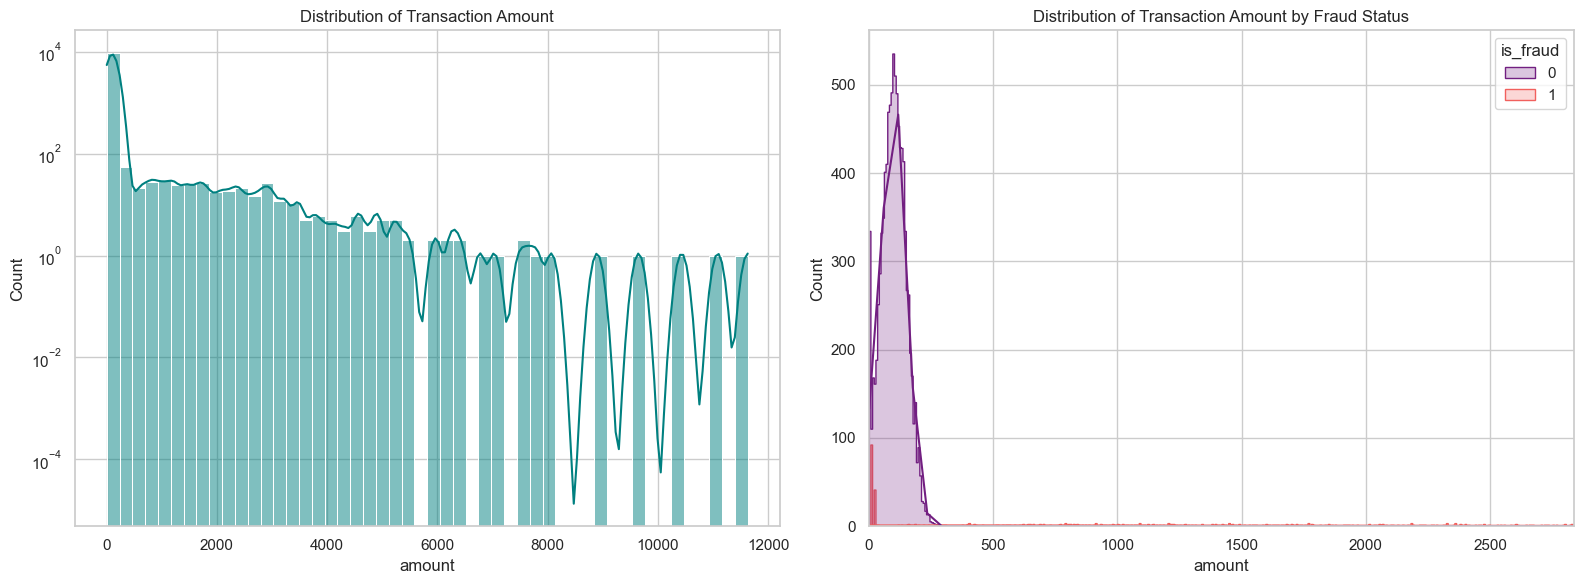

In [36]:


# 1. Define the figure and axes first!
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

sns.set_theme(style="whitegrid")

# 2. Plot on the first axis (axs[0])
sns.histplot(data=df, x="amount", bins=50, kde=True, color='teal', ax=axs[0])
axs[0].set_yscale('log')
axs[0].set_title('Distribution of Transaction Amount')

# 3. Plot on the second axis (axs[1])
sns.histplot(data=df, x='amount', hue='is_fraud', kde=True, 
             element='step', palette='magma', ax=axs[1])
axs[1].set_xlim(0, df['amount'].quantile(0.99))
axs[1].set_title('Distribution of Transaction Amount by Fraud Status')

plt.tight_layout()
plt.show()

Numerical Columns

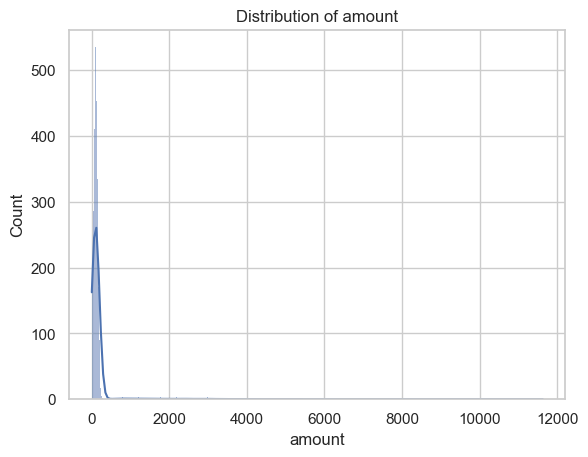

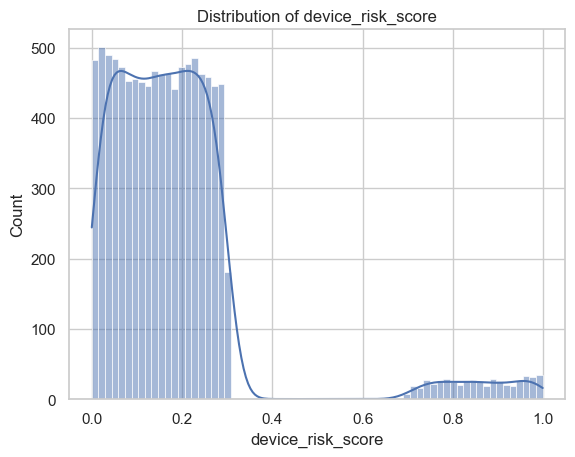

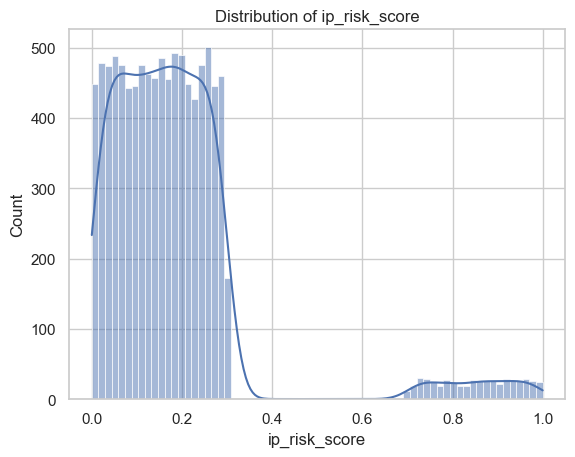

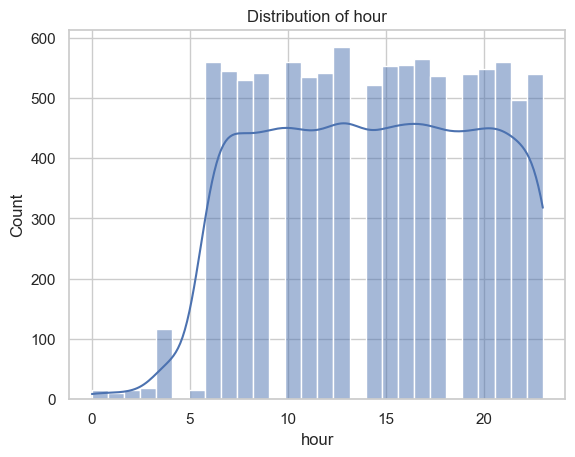

In [43]:
num_cols = ['amount', 'device_risk_score', 'ip_risk_score', 'hour']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Boxplot (Outlier Detection 🚨)

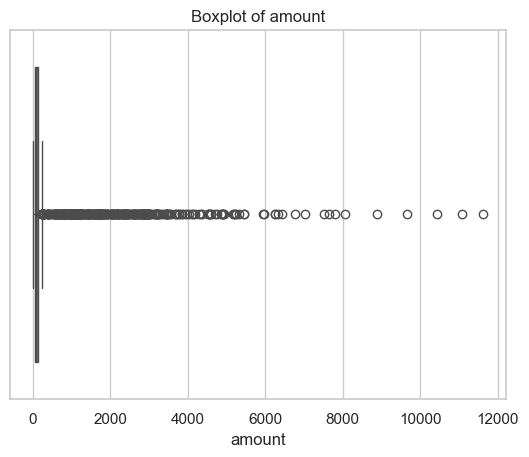

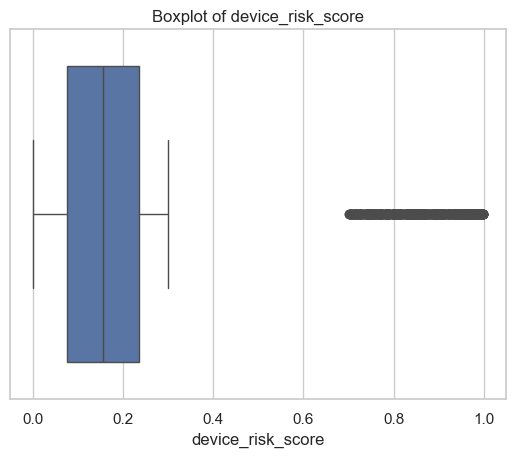

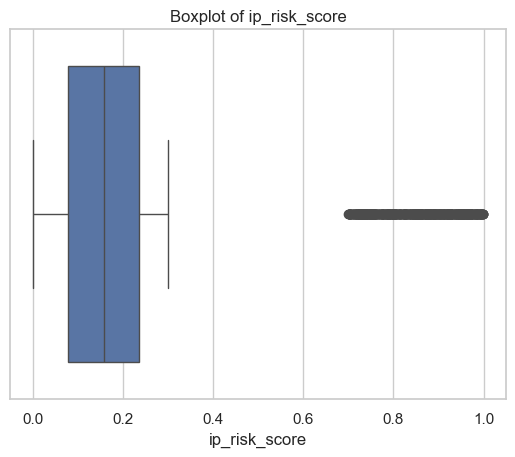

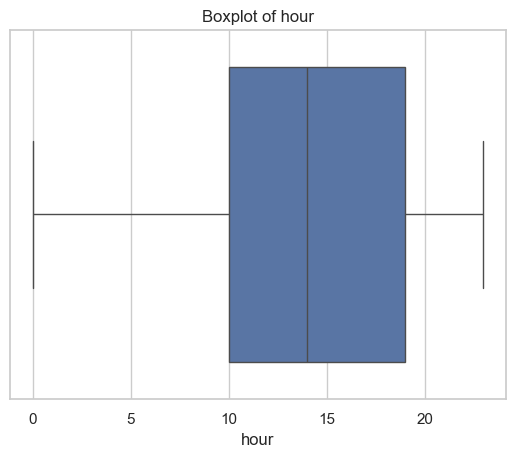

In [44]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Categorical Columns

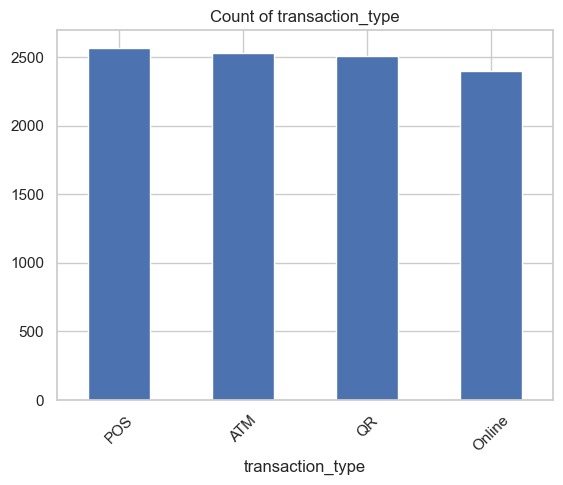

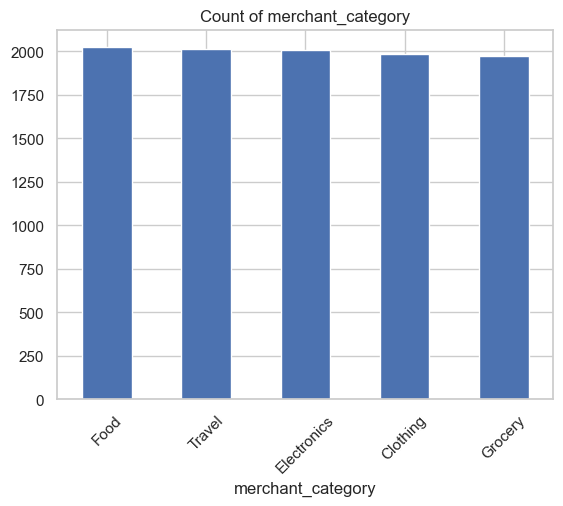

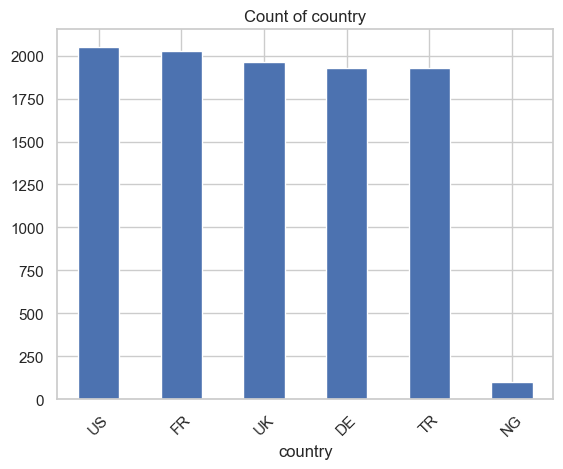

In [45]:
cat_cols = ['transaction_type', 'merchant_category', 'country']

for col in cat_cols:
    plt.figure()
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()

Target Variable

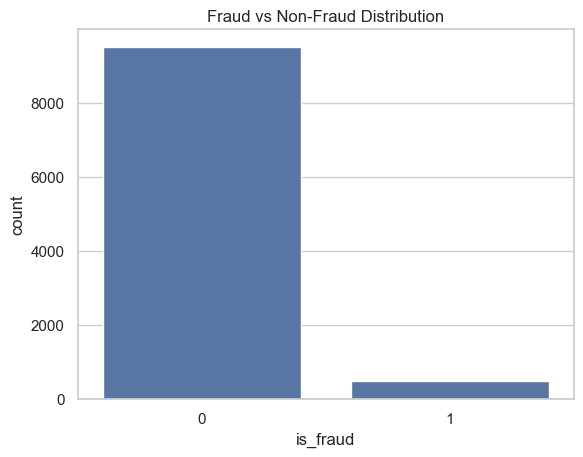

In [46]:
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

BIVARIATE ANALYSIS

Fraud vs Numerical Features

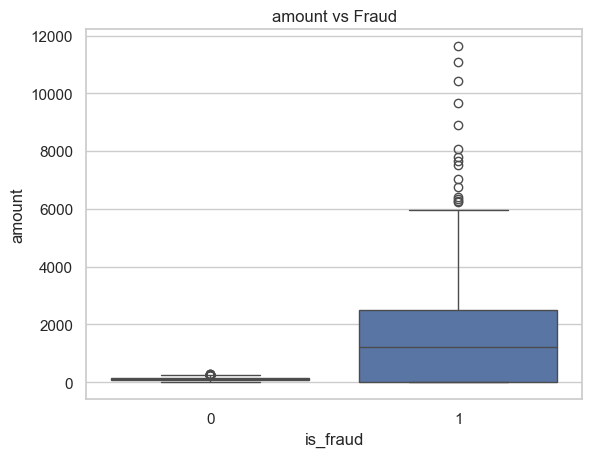

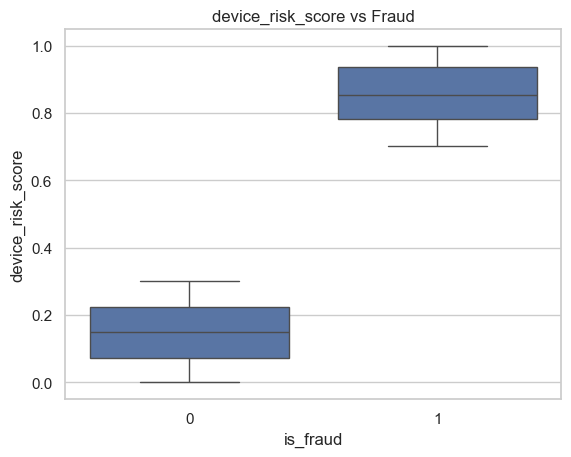

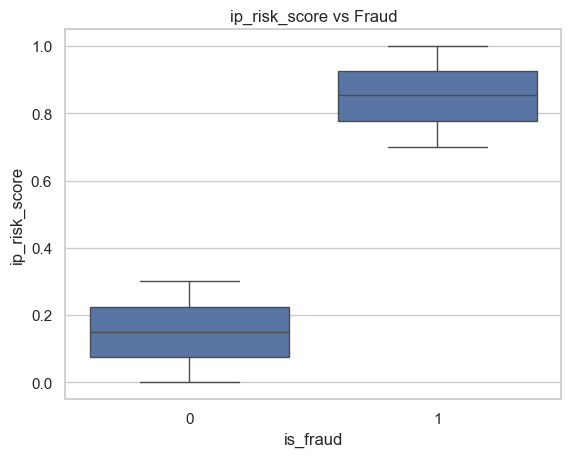

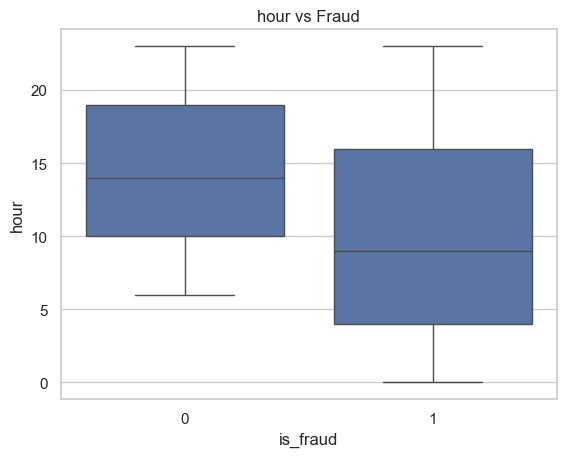

In [47]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x='is_fraud', y=col, data=df)
    plt.title(f'{col} vs Fraud')
    plt.show()

Fraud vs Categorical Features

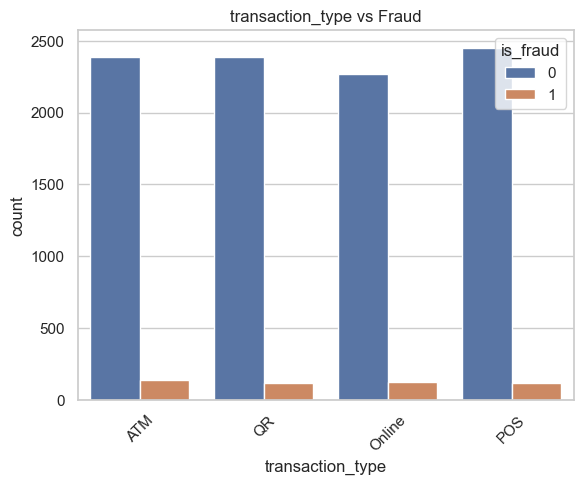

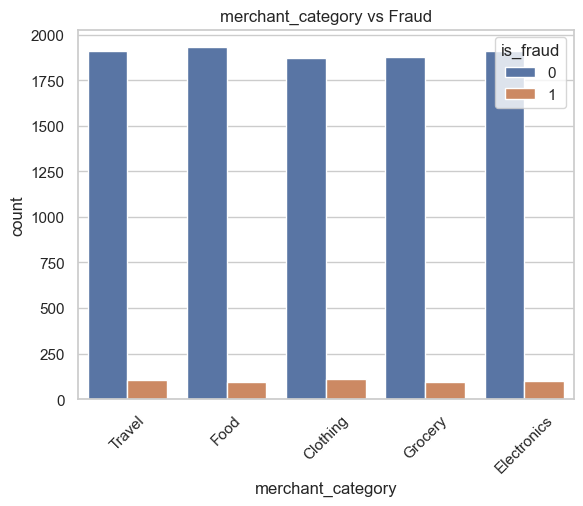

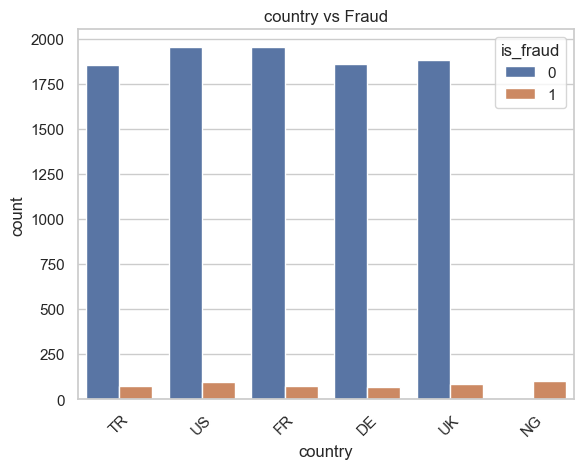

In [48]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='is_fraud', data=df)
    plt.title(f'{col} vs Fraud')
    plt.xticks(rotation=45)
    plt.show()

Correlation Heatmap

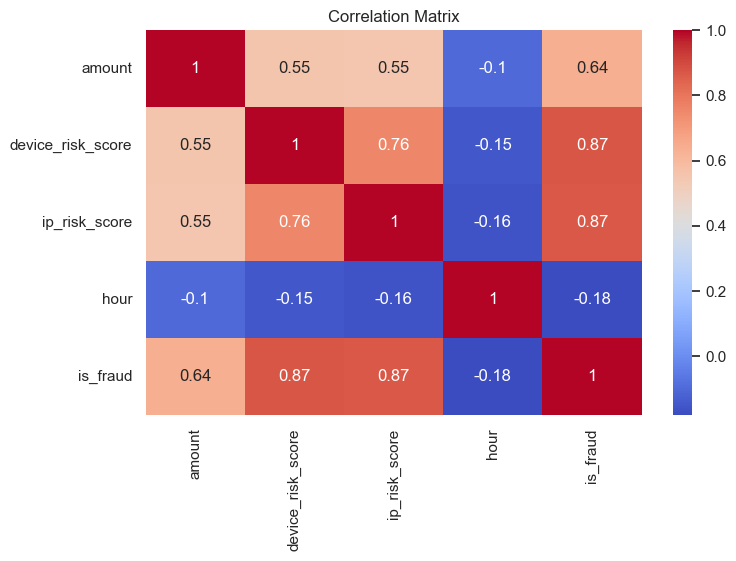

In [49]:
plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols + ['is_fraud']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

MULTIVARIATE ANALYSIS

Pairplot

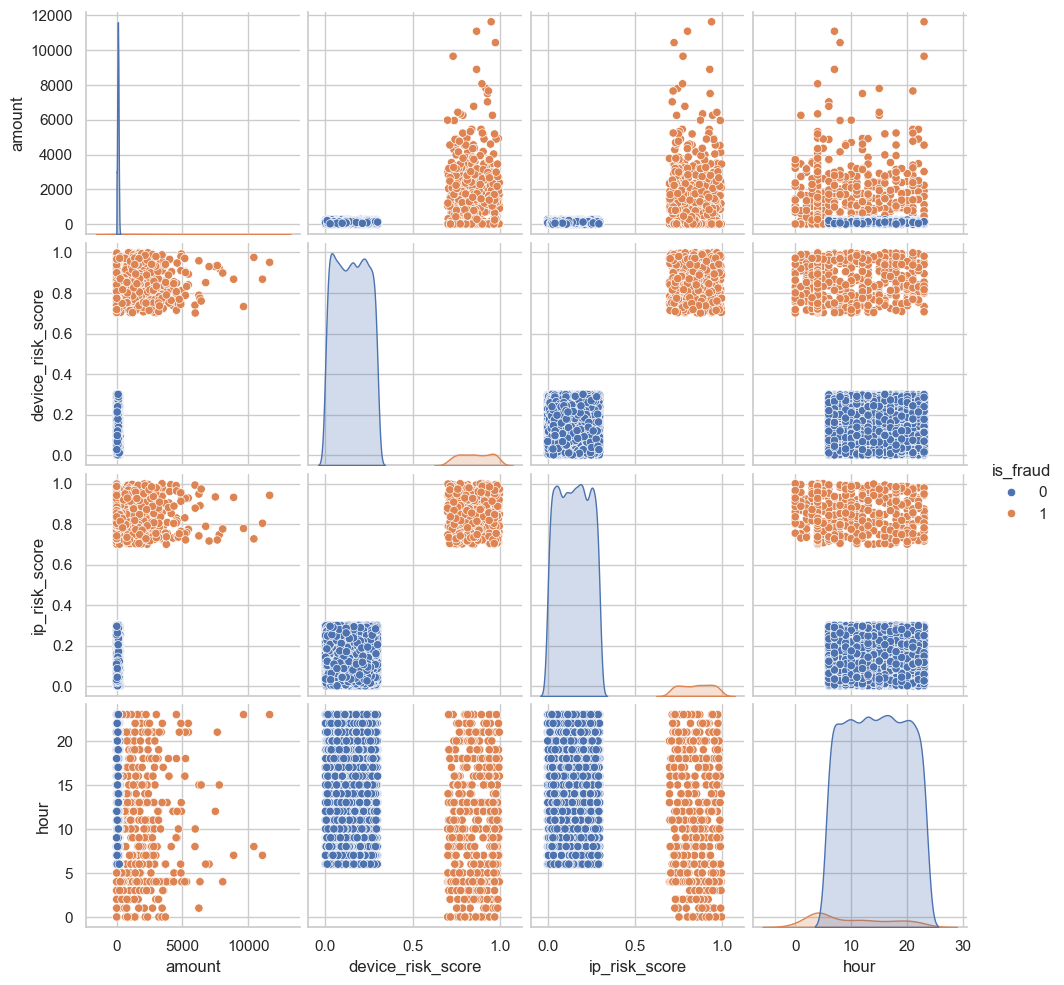

In [50]:
sns.pairplot(df[num_cols + ['is_fraud']], hue='is_fraud')
plt.show()

Pivot Table Analysis

In [51]:
pivot = pd.pivot_table(
    df,
    values='amount',
    index='merchant_category',
    columns='is_fraud',
    aggfunc='mean'
)

print(pivot)

is_fraud                    0            1
merchant_category                         
Clothing            98.755016  1535.848804
Electronics        100.625198  1506.743429
Food                99.380970  1588.472352
Grocery            100.764676  1871.514820
Travel             101.852422  1790.445771


Group Analysis

In [52]:
grouped = df.groupby(['country', 'is_fraud'])['amount'].mean().reset_index()
print(grouped)

   country  is_fraud       amount
0       DE         0    99.462355
1       DE         1  1661.917947
2       FR         0   102.271229
3       FR         1  1594.368929
4       NG         1  1407.264279
5       TR         0   101.129284
6       TR         1  1916.763437
7       UK         0    98.682371
8       UK         1  1616.944181
9       US         0    99.789075
10      US         1  1795.973316


PIE PLOTS

Fraud Distribution

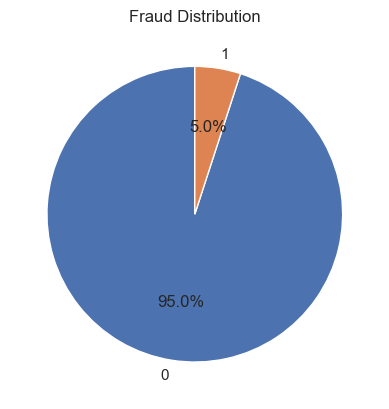

In [53]:
df['is_fraud'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Fraud Distribution")
plt.ylabel('')
plt.show()

Transaction Type Distribution

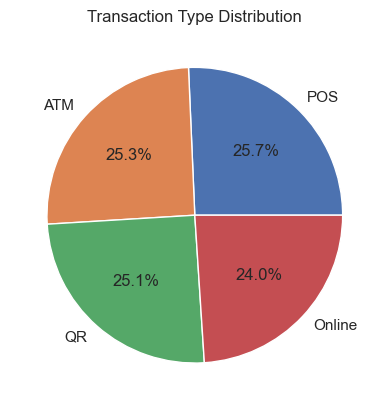

In [54]:
df['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Transaction Type Distribution")
plt.ylabel('')
plt.show()

Merchant Category

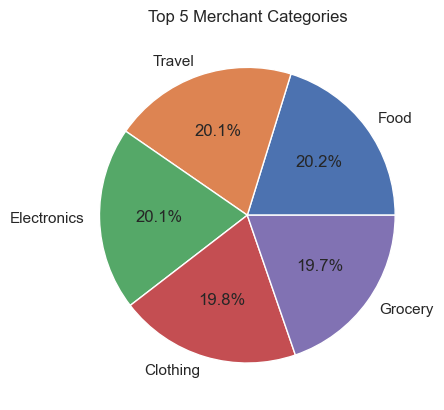

In [55]:
df['merchant_category'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Top 5 Merchant Categories")
plt.ylabel('')
plt.show()

Fraud Rate by Category

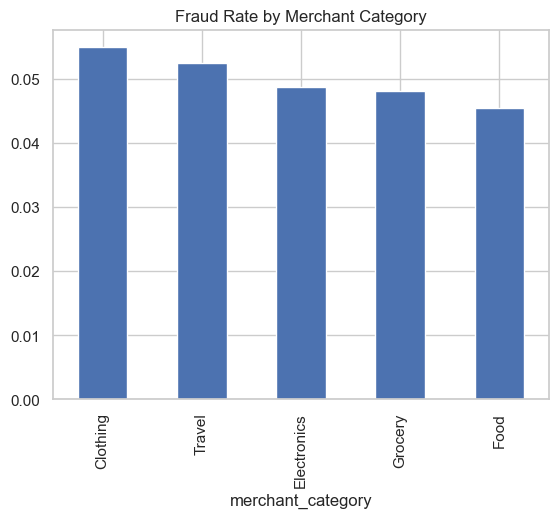

In [56]:
fraud_rate = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)

fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Merchant Category")
plt.show()

"performed univariate analysis to understand distribution and detect outliers."
"Bivariate analysis helped me identify relationships between fraud and risk scores."
"Multivariate analysis like pairplot and correlation matrix helped in feature selection."
"I identified high-risk merchant categories and countries contributing to fraud."